# Symbolická matematika v Jupyter Notebooku

Tento notebook predstavuje piatu a zároveň jedinečnú ukážkovú 
funkcionalitu Jupyter Notebooku: symbolickú matematiku pomocou 
knižnice SymPy. Na rozdiel od predchádzajúcich notebookov, 
kde sme počítali numericky, SymPy pracuje s matematickými 
výrazmi analyticky, teda presne tak ako pri ručnom výpočte 
na papieri.

Výsledky sa zobrazujú v matematickej notácii priamo v bunke 
notebooku. Jupyter Notebook sa tak stáva nielen nástrojom 
na vykresľovanie grafov, ale plnohodnotným prostredím pre 
analytickú matematiku schopným nahradiť klasické odvodenia 
na tabuli.

## Čo SymPy dokáže

| Operácia | Príkaz | Popis |
|----------|--------|-------|
| Derivovanie | `sp.diff(f, x)` | Derivácia funkcie f podľa x |
| Integrovanie | `sp.integrate(f, x)` | Neurčitý integrál |
| Určitý integrál | `sp.integrate(f, (x, a, b))` | Integrál od a do b |
| Riešenie rovníc | `sp.solve(eq, x)` | Analytické riešenie |
| Diferenciálne rovnice | `sp.dsolve(ode, f(x))` | Riešenie ODE |
| Limity | `sp.limit(f, x, a)` | Limita funkcie |
| Taylorov rad | `sp.series(f, x, a, n)` | Rozvoj do radu |
| Zjednodušenie | `sp.simplify(expr)` | Zjednodušenie výrazu |
| Dosadenie | `expr.subs(x, hodnota)` | Dosadenie hodnoty |
| LaTeX výstup | `sp.latex(expr)` | Generovanie LaTeX kódu |

In [10]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

sp.init_printing(use_latex=True)
%matplotlib inline
plt.style.use('dark_background')

print("SymPy verzia:", sp.__version__)
print("Symbolický výstup aktivovaný.")

SymPy verzia: 1.14.0
Symbolický výstup aktivovaný.


## 1. Definícia symbolických premenných

V SymPy musíme najprv deklarovať symbolické premenné. 
Môžeme pritom špecifikovať ich vlastnosti, napríklad 
či sú reálne, kladné alebo celé čísla. Tieto vlastnosti 
SymPy využíva pri zjednodušovaní výrazov.

In [11]:
# Základné fyzikálne premenné
t = sp.Symbol('t', real=True, positive=True)    # čas
x = sp.Symbol('x', real=True)                   # poloha

# Parametrické konštanty
s0  = sp.Symbol('s_0',  real=True)              # počiatočná poloha
v0  = sp.Symbol('v_0',  real=True)              # počiatočná rýchlosť
a0  = sp.Symbol('a_0',  real=True)              # zrýchlenie
m   = sp.Symbol('m',    positive=True)          # hmotnosť
k   = sp.Symbol('k',    positive=True)          # tuhosť pružiny
b   = sp.Symbol('b',    nonnegative=True)       # koeficient tlmenia
g   = sp.Symbol('g',    positive=True)          # gravitačné zrýchlenie
P   = sp.Symbol('P',    positive=True)          # výkon motora
v   = sp.Symbol('v',    positive=True)          # rýchlosť

print("Všetky symbolické premenné definované.")
print("Vlastnosti premenných informujú SymPy")
print("ako s nimi zaobchádzať pri zjednodušovaní.")

Všetky symbolické premenné definované.
Vlastnosti premenných informujú SymPy
ako s nimi zaobchádzať pri zjednodušovaní.


## 2. Kinematika – odvodzovanie základných vzťahov

Začneme s polohou vozidla ako polynomickou funkciou času 
a symbolicky odvodíme rýchlosť a zrýchlenie derivovaním. 
Toto je presne to, čo by sme robili na tabuli, len 
Jupyter Notebook to urobí za nás a výsledok zobrazí 
v matematickej notácii.

In [12]:
print("=" * 55)
print("  KINEMATIKA: Odvodzovanie základných vzťahov")
print("=" * 55)

# Poloha ako funkcia času
s_t = s0 + v0*t + sp.Rational(1,2)*a0*t**2

print("\nPoloha s(t):")
display(sp.Eq(sp.Function('s')(t), s_t))

# Prvá derivácia = rýchlosť
v_t = sp.diff(s_t, t)
print("\nRýchlosť v(t) = ds/dt:")
display(sp.Eq(sp.Function('v')(t), v_t))

# Druhá derivácia = zrýchlenie
a_t = sp.diff(s_t, t, 2)
print("\nZrýchlenie a(t) = d²s/dt²:")
display(sp.Eq(sp.Function('a')(t), a_t))

print("\nZrýchlenie je konštanta a₀, čo potvrdzuje")
print("rovnomerne zrýchlený pohyb.")

  KINEMATIKA: Odvodzovanie základných vzťahov

Poloha s(t):



Rýchlosť v(t) = ds/dt:



Zrýchlenie a(t) = d²s/dt²:



Zrýchlenie je konštanta a₀, čo potvrdzuje
rovnomerne zrýchlený pohyb.


## 3. Brzdná dráha – analytické odvodenie

Vypočítame brzdnú dráhu dvoma spôsobmi: 
integrovaním rýchlosti a z kinematickej rovnice. 
SymPy overí že obe metódy dajú rovnaký výsledok.

In [13]:
print("=" * 55)
print("  BRZDNÁ DRÁHA: Dve metódy, jeden výsledok")
print("=" * 55)

a_brz = sp.Symbol('a_b', negative=True)   # záporné spomalenie
v0_b  = sp.Symbol('v_0', positive=True)

# Čas zastavenia
t_stop = sp.solve(v0_b + a_brz*t, t)[0]
print("\nČas zastavenia (v = 0):")
display(sp.Eq(sp.Symbol('t_{stop}'), t_stop))

# Metóda 1: integrovanie rýchlosti
v_brzd = v0_b + a_brz*t
s_int  = sp.integrate(v_brzd, (t, 0, t_stop))
s_int  = sp.simplify(s_int)
print("\nMetóda 1 – integrovaním rýchlosti:")
display(sp.Eq(sp.Symbol('s_{brzdenie}'), s_int))

# Metóda 2: z kinematickej rovnice v² = v₀² + 2as
# pri v=0: s = -v₀²/(2a)
s_kin = sp.Rational(-1,2) * v0_b**2 / a_brz
print("\nMetóda 2 – z kinematickej rovnice v²=v₀²+2as:")
display(sp.Eq(sp.Symbol('s_{brzdenie}'), s_kin))

# Overenie rovnosti
rovnost = sp.simplify(s_int - s_kin)
print(f"\nRozdiel výsledkov (má byť 0): {rovnost}")
print("Oba spôsoby dávajú rovnaký výsledok.")

# Numerický príklad
print("\n" + "─"*55)
print("  Príklad: v₀ = 90 km/h, spomalenie = 6 m/s²")
print("─"*55)
v0_num = 90/3.6
a_num  = -6
s_num  = float(s_int.subs([(v0_b, v0_num), (a_brz, a_num)]))
print(f"  Brzdná dráha = {s_num:.2f} m")

  BRZDNÁ DRÁHA: Dve metódy, jeden výsledok

Čas zastavenia (v = 0):



Metóda 1 – integrovaním rýchlosti:



Metóda 2 – z kinematickej rovnice v²=v₀²+2as:



Rozdiel výsledkov (má byť 0): 0
Oba spôsoby dávajú rovnaký výsledok.

───────────────────────────────────────────────────────
  Príklad: v₀ = 90 km/h, spomalenie = 6 m/s²
───────────────────────────────────────────────────────
  Brzdná dráha = 52.08 m


## 4. Energia vozidla – práca a výkon

Vypočítame kinetickú energiu, prácu vykonanú brzdnou silou 
a overíme energetickú bilanciu symbolicky. Toto je 
klasický fyzikálny výpočet, ktorý SymPy zvládne v plnej 
symbolickej forme.

In [14]:
print("=" * 55)
print("  ENERGIA: Kinetická energia a práca")
print("=" * 55)

v_sym = sp.Symbol('v', positive=True)
F_sym = sp.Symbol('F', positive=True)
s_sym = sp.Symbol('s', positive=True)

# Kinetická energia
E_k = sp.Rational(1,2) * m * v_sym**2
print("\nKinetická energia:")
display(sp.Eq(sp.Symbol('E_k'), E_k))

# Derivácia kinetickej energie podľa rýchlosti
dEk_dv = sp.diff(E_k, v_sym)
print("\ndE_k/dv = p (hybnosť):")
display(sp.Eq(sp.Symbol('dE_k/dv'), dEk_dv))

# Práca = sila × dráha
W = F_sym * s_sym
print("\nPráca W = F·s:")
display(sp.Eq(sp.Symbol('W'), W))

# Výkon = dW/dt = F·v
t_sym = sp.Symbol('t', positive=True)
s_cas = v_sym * t_sym
W_cas = F_sym * s_cas
P_sym = sp.diff(W_cas, t_sym)
print("\nVýkon P = dW/dt = F·v:")
display(sp.Eq(sp.Symbol('P'), P_sym))

# Hnacia sila z výkonu
F_motor = P / v_sym
print("\nHnacia sila motora F = P/v:")
display(sp.Eq(sp.Symbol('F_{motor}'), F_motor))

# Numerický príklad
print("\n" + "─"*55)
print("  Príklad: P = 100 kW, v = 50 km/h = 13.9 m/s")
print("─"*55)
F_num = float(F_motor.subs([(P, 100000), (v_sym, 50/3.6)]))
print(f"  Hnacia sila = {F_num:.1f} N")

  ENERGIA: Kinetická energia a práca

Kinetická energia:



dE_k/dv = p (hybnosť):



Práca W = F·s:



Výkon P = dW/dt = F·v:



Hnacia sila motora F = P/v:



───────────────────────────────────────────────────────
  Príklad: P = 100 kW, v = 50 km/h = 13.9 m/s
───────────────────────────────────────────────────────
  Hnacia sila = 7200.0 N


## 5. Pohybová rovnica oscilátora 

Toto je najsilnejšia ukážka SymPy: analytické riešenie 
diferenciálnej rovnice druhého rádu. SymPy nájde všeobecné 
riešenie pohybovej rovnice tlmeného oscilátora vrátane 
integračných konštánt.

  ODE: Analytické riešenie pohybovej rovnice

Pohybová rovnica:


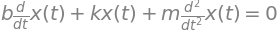


Všeobecné riešenie (SymPy):



Vysvetlenie:
C1, C2 sú integračné konštanty určené
z počiatočných podmienok x(0) a v(0).


In [15]:
print("=" * 55)
print("  ODE: Analytické riešenie pohybovej rovnice")
print("=" * 55)

# Symbolická funkcia x(t)
x_fn = sp.Function('x')

# Pohybová rovnica: m*x'' + b*x' + k*x = 0
ode = sp.Eq(
    m * x_fn(t).diff(t,2) + b * x_fn(t).diff(t) + k * x_fn(t),
    0
)
print("\nPohybová rovnica:")
display(ode)

# Všeobecné riešenie
print("\nVšeobecné riešenie (SymPy):")
riesenie = sp.dsolve(ode, x_fn(t))
display(riesenie)

print("\nVysvetlenie:")
print("C1, C2 sú integračné konštanty určené")
print("z počiatočných podmienok x(0) a v(0).")

## 6. Charakteristická rovnica a vlastné frekvencie

Analyticky odvodíme vlastnú uhlovú frekvenciu, periódu 
kmitania a kritické tlmenie. Tieto vzorce sú základom 
pre návrh tlmičov a pružinových sústav.

  VLASTNÉ FREKVENCIE: Symbolické odvodenie

Vlastná uhlová frekvencia ω₀:



Perióda kmitania T = 2π/ω₀:



Kritické tlmenie b_krit = 2√(km):



Pomer tlmenia ζ = b/b_krit:


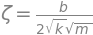


Režimy tlmenia:
  ζ < 1  →  podtlmený  (kmitanie s útlmom)
  ζ = 1  →  kritický   (najrýchlejší návrat)
  ζ > 1  →  pretlmený  (pomalý návrat)

Tlmená frekvencia ω_d = ω₀·√(1-ζ²):


In [16]:
print("=" * 55)
print("  VLASTNÉ FREKVENCIE: Symbolické odvodenie")
print("=" * 55)

# Vlastná uhlová frekvencia
omega0_sym = sp.sqrt(k/m)
print("\nVlastná uhlová frekvencia ω₀:")
display(sp.Eq(sp.Symbol('omega_0'), omega0_sym))

# Perióda kmitania
T_sym = 2 * sp.pi / omega0_sym
T_zjedn = sp.simplify(T_sym)
print("\nPerióda kmitania T = 2π/ω₀:")
display(sp.Eq(sp.Symbol('T'), T_zjedn))

# Kritické tlmenie
b_krit_sym = 2 * sp.sqrt(k*m)
print("\nKritické tlmenie b_krit = 2√(km):")
display(sp.Eq(sp.Symbol('b_{krit}'), b_krit_sym))

# Pomer tlmenia (damping ratio)
zeta = b / b_krit_sym
zeta_zjedn = sp.simplify(zeta)
print("\nPomer tlmenia ζ = b/b_krit:")
display(sp.Eq(sp.Symbol('zeta'), zeta_zjedn))

print("\nRežimy tlmenia:")
print("  ζ < 1  →  podtlmený  (kmitanie s útlmom)")
print("  ζ = 1  →  kritický   (najrýchlejší návrat)")
print("  ζ > 1  →  pretlmený  (pomalý návrat)")

# Symbolický výpočet tlmenej frekvencie
omega_d = omega0_sym * sp.sqrt(1 - zeta_zjedn**2)
omega_d_zjedn = sp.simplify(omega_d)
print("\nTlmená frekvencia ω_d = ω₀·√(1-ζ²):")
display(sp.Eq(sp.Symbol('omega_d'), omega_d_zjedn))

## 7. Taylorov rozvoj – aproximácia funkcií

SymPy dokáže rozvinúť ľubovoľnú funkciu do Taylorovho radu. 
Toto je užitočné pri linearizácii nelineárnych rovníc, 
čo je bežná technika v strojárstve pri analýze malých kmitov.

  TAYLOROV ROZVOJ: Aproximácia sin(x)

Taylorov rozvoj sin(x) okolo x=0:

  Stupeň 3:



  Stupeň 5:



  Stupeň 7:



  Stupeň 9:



Vizualizácia aproximácií:


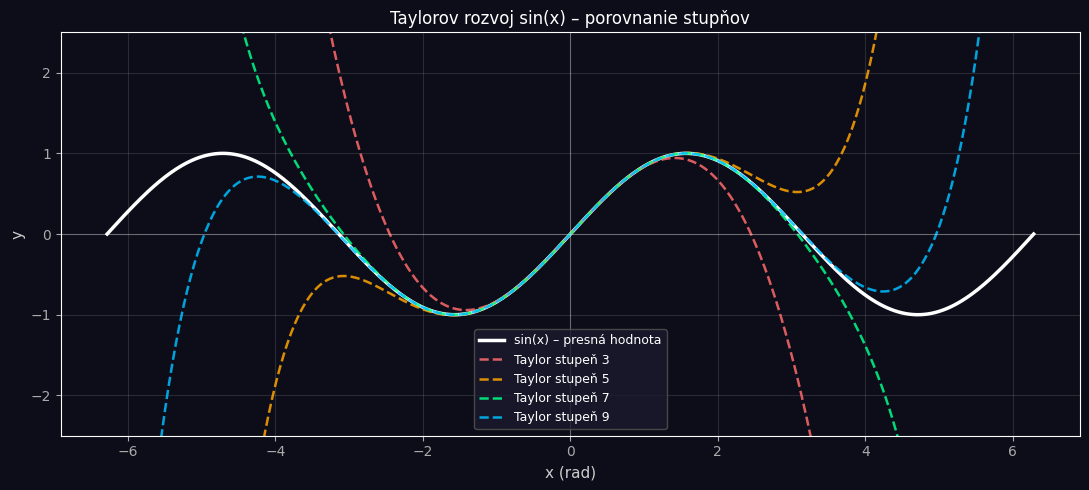

Čím vyšší stupeň, tým presnejšia aproximácia
na väčšom intervale.


In [8]:
print("=" * 55)
print("  TAYLOROV ROZVOJ: Aproximácia sin(x)")
print("=" * 55)

x_sym = sp.Symbol('x')

# Taylorov rozvoj sin(x) okolo 0
print("\nTaylorov rozvoj sin(x) okolo x=0:")
for n in [3, 5, 7, 9]:
    rad = sp.series(sp.sin(x_sym), x_sym, 0, n+1).removeO()
    print(f"\n  Stupeň {n}:")
    display(sp.Eq(sp.Symbol(f'sin(x) ≈ T_{n}(x)'), rad))

# Vizualizácia
print("\nVizualizácia aproximácií:")
x_num = np.linspace(-2*np.pi, 2*np.pi, 500)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')

ax.plot(x_num, np.sin(x_num), color='white', lw=2.5,
        label='sin(x) – presná hodnota')

farby = ['#FF6B6B', '#FFA500', '#00FF88', '#00BFFF']
for n, farba in zip([3, 5, 7, 9], farby):
    rad_fn = sp.lambdify(x_sym,
                          sp.series(sp.sin(x_sym), x_sym, 0, n+1).removeO(),
                          'numpy')
    y = rad_fn(x_num)
    ax.plot(x_num, y, color=farba, lw=1.8, linestyle='--',
            label=f'Taylor stupeň {n}', alpha=0.85)

ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('x (rad)', color='#cccccc', fontsize=11)
ax.set_ylabel('y', color='#cccccc', fontsize=11)
ax.set_title('Taylorov rozvoj sin(x) – porovnanie stupňov',
             color='white', fontsize=12)
ax.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='#555555')
ax.grid(True, alpha=0.12)
ax.tick_params(colors='#aaaaaa')
ax.axhline(y=0, color='white', lw=0.8, alpha=0.3)
ax.axvline(x=0, color='white', lw=0.8, alpha=0.3)

plt.tight_layout()
plt.show()

print("Čím vyšší stupeň, tým presnejšia aproximácia")
print("na väčšom intervale.")

## 8. Interaktívne dosadzovanie a generovanie LaTeX

SymPy dokáže automaticky vygenerovať LaTeX kód 
pre ľubovoľný výraz. Toto je užitočné pri písaní 
odborných textov a záverečných prác.

In [9]:
out = widgets.Output()

def zobraz_sympy(m_val, k_val, b_val):
    omega0_val  = float(sp.sqrt(k_val / m_val))
    T_val       = float(2 * np.pi / omega0_val)
    b_krit_val  = float(2 * np.sqrt(k_val * m_val))
    pomer       = b_val / b_krit_val

    if pomer < 0.99:
        rezim = 'PODTLMENÝ'
        farba_r = '#00FF88'
    elif pomer <= 1.01:
        rezim = 'KRITICKY TLMENÝ'
        farba_r = '#FFD700'
    else:
        rezim = 'PRETLMENÝ'
        farba_r = '#FF6B6B'

    from scipy.integrate import solve_ivp
    t_sim = np.linspace(0, 6*T_val, 1500)
    sol   = solve_ivp(
        lambda t, y: [y[1], (-b_val*y[1] - k_val*y[0])/m_val],
        (0, 6*T_val), [1.0, 0.0],
        t_eval=t_sim, method='RK45', rtol=1e-8
    )

    with out:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        fig.patch.set_facecolor('#0d0d1a')

        # Výchylka
        ax1 = axes[0]
        ax1.set_facecolor('#0d0d1a')
        ax1.plot(sol.t, sol.y[0], color='#00BFFF', lw=2.2)
        ax1.axhline(y=0, color='white', lw=1, ls='--', alpha=0.3)
        if pomer < 1:
            alpha_d = b_val / (2*m_val)
            ax1.plot(sol.t,  np.exp(-alpha_d*sol.t),
                     color='#FFD700', lw=1.5, ls='--',
                     alpha=0.7, label='Obálka')
            ax1.plot(sol.t, -np.exp(-alpha_d*sol.t),
                     color='#FFD700', lw=1.5, ls='--', alpha=0.7)
            ax1.legend(fontsize=8, facecolor='#1a1a2e')
        ax1.fill_between(sol.t, sol.y[0], 0,
                         where=(sol.y[0]>=0), alpha=0.1, color='#00BFFF')
        ax1.fill_between(sol.t, sol.y[0], 0,
                         where=(sol.y[0]<0),  alpha=0.1, color='#FF6B6B')
        ax1.set_xlabel('Čas t (s)', color='#cccccc')
        ax1.set_ylabel('Výchylka x (m)', color='#cccccc')
        ax1.set_title(f'Výchylka\nRežim: {rezim}',
                      color=farba_r, fontsize=10)
        ax1.grid(True, alpha=0.12)
        ax1.tick_params(colors='#aaaaaa')

        # Fázový diagram
        ax2 = axes[1]
        ax2.set_facecolor('#0d0d1a')
        sc = ax2.scatter(sol.y[0], sol.y[1],
                         c=sol.t, cmap='plasma', s=2, alpha=0.8)
        ax2.axhline(y=0, color='white', lw=0.8, alpha=0.3)
        ax2.axvline(x=0, color='white', lw=0.8, alpha=0.3)
        ax2.set_xlabel('Výchylka x (m)', color='#cccccc')
        ax2.set_ylabel('Rýchlosť v (m/s)', color='#cccccc')
        ax2.set_title('Fázový diagram', color='white', fontsize=10)
        ax2.grid(True, alpha=0.12)
        ax2.tick_params(colors='#aaaaaa')
        plt.colorbar(sc, ax=ax2, label='Čas (s)')

        # Porovnanie všetkých troch režimov
        ax3 = axes[2]
        ax3.set_facecolor('#0d0d1a')
        for b_por, farba, nazov in [
            (b_krit_val*0.3, '#00FF88', 'Podtlmený'),
            (b_krit_val*1.0, '#FFD700', 'Kritický'),
            (b_krit_val*3.0, '#FF6B6B', 'Pretlmený')
        ]:
            sol_p = solve_ivp(
                lambda t, y: [y[1],
                               (-b_por*y[1]-k_val*y[0])/m_val],
                (0, 6*T_val), [1.0, 0.0],
                t_eval=t_sim, method='RK45'
            )
            ax3.plot(sol_p.t, sol_p.y[0], color=farba,
                     lw=1.8, label=nazov, alpha=0.9)
        ax3.axhline(y=0, color='white', lw=0.8, alpha=0.3)
        ax3.set_xlabel('Čas t (s)', color='#cccccc')
        ax3.set_ylabel('Výchylka x (m)', color='#cccccc')
        ax3.set_title('Porovnanie režimov', color='white', fontsize=10)
        ax3.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#555555')
        ax3.grid(True, alpha=0.12)
        ax3.tick_params(colors='#aaaaaa')

        fig.suptitle(
            f'SymPy  │  m={m_val} kg  │  k={k_val} N/m  │  '
            f'b={b_val} N·s/m  │  ζ={pomer:.3f}',
            fontsize=11, color='white', y=1.02
        )
        plt.tight_layout()
        plt.show()

        # Symbolické výsledky s dosadením
        print(f'{"═"*55}')
        print(f'  Symbolicky odvodené, numericky dosadené:')
        print(f'{"─"*55}')
        print(f'  ω₀ = √(k/m) = √({k_val}/{m_val})'
              f' = {omega0_val:.4f} rad/s')
        print(f'  f₀ = ω₀/(2π) = {omega0_val/(2*np.pi):.4f} Hz')
        print(f'  T  = 2π/ω₀  = {T_val:.4f} s')
        print(f'  b_krit = 2√(km) = {b_krit_val:.4f} N·s/m')
        print(f'  ζ = b/b_krit   = {pomer:.4f}')
        print(f'{"─"*55}')
        print(f'  Režim tlmenia:  {rezim}')
        print(f'{"─"*55}')

        # LaTeX kód pre vzorce
        print(f'  LaTeX kód pre ω₀:')
        print(f'  ${sp.latex(sp.sqrt(k/m))}$')
        print(f'\n  LaTeX kód pre T:')
        print(f'  ${sp.latex(2*sp.pi/sp.sqrt(k/m))}$')
        print(f'\n  LaTeX kód pre b_krit:')
        print(f'  ${sp.latex(2*sp.sqrt(k*m))}$')
        print(f'{"═"*55}')


widgets.interact(
    zobraz_sympy,
    m_val=widgets.FloatSlider(
        value=1.0, min=0.1, max=5.0, step=0.1,
        description='Hmotnosť m (kg):',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='500px')),
    k_val=widgets.FloatSlider(
        value=10.0, min=1.0, max=100.0, step=1.0,
        description='Tuhosť k (N/m):',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='500px')),
    b_val=widgets.FloatSlider(
        value=1.0, min=0.0, max=30.0, step=0.5,
        description='Tlmenie b (N·s/m):',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='500px'))
)

display(out)

interactive(children=(FloatSlider(value=1.0, description='Hmotnosť m (kg):', layout=Layout(width='500px'), max…

Output()

## Záver

Tento notebook ukázal SymPy ako plnohodnotný nástroj 
pre analytickú matematiku v Jupyter Notebooku.

- **Derivovanie**  - polohy dalo exaktné vzorce pre rýchlosť 
  a zrýchlenie bez numerickej chyby
- **Integrovanie** - rýchlosti dalo presný vzorec brzdnej dráhy, 
  overený dvoma nezávislými metódami
- **Energetická analýza** - symbolicky odvodila vzťah medzi 
  výkonom, silou a rýchlosťou
- **Analytické riešenie ODE** - poskytlo všeobecné riešenie 
  pohybovej rovnice tlmeného oscilátora
- **Taylorov rozvoj** - demonštroval linearizáciu nelineárnych 
  funkcií, kľúčovú techniku v strojárstve
- **LaTeX generovanie** - umožňuje priamo exportovať vzorce 
  do odborných textov a záverečných prác

Jupyter Notebook spojením SymPy, NumPy, SciPy a Matplotlib 
pokrýva celý rozsah matematických výpočtov potrebných
pre výučbu fyziky v technickom vzdelávaní.